# Análisis Exploratorio de Datos - Clasificación de Residuos

Este notebook realiza un análisis exploratorio del dataset de clasificación de residuos.

## Clases del Dataset
1. **Glass** (Vidrio)
2. **Paper** (Papel)
3. **Cardboard** (Cartón)
4. **Plastic** (Plástico)
5. **Metal**
6. **Trash** (Basura general)

## Objetivos
1. Verificar la estructura del dataset
2. Analizar la distribución de clases
3. Explorar características de las imágenes
4. Visualizar muestras de cada clase
5. Identificar posibles problemas

## 1. Configuración Inicial

In [ ]:
# Importar bibliotecas básicas
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import pandas as pd

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Definir rutas
DATA_DIR = Path('../data/raw/garbage_classification')
FIGURES_DIR = Path('../figures/eda')

# Crear directorio de figuras si no existe
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Bibliotecas cargadas correctamente')
print(f'📁 Directorio de datos: {DATA_DIR}')
print(f'📊 Directorio de figuras: {FIGURES_DIR}')

Bibliotecas cargadas correctamente
Directorio de datos: ..\data\raw\garbage_classification


## 2. Verificación del Dataset

In [10]:
# Verificar que el directorio existe
if not DATA_DIR.exists():
    print(f'ERROR: No se encuentra el directorio {DATA_DIR}')
    print('Por favor, verifica que los datos estén en la ubicación correcta.')
else:
    print(f'Directorio encontrado: {DATA_DIR}')
    
    # Listar subdirectorios (clases)
    classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
    
    print(f'\nNúmero de clases: {len(classes)}')
    print(f'Clases: {", ".join(classes)}')

Directorio encontrado: ..\data\raw\garbage_classification

Número de clases: 6
Clases: cardboard, glass, metal, paper, plastic, trash


## 3. Análisis de Distribución de Clases

In [11]:
# Contar imágenes por clase
class_counts = {}

for class_name in classes:
    class_path = DATA_DIR / class_name
    # Contar archivos de imagen
    image_files = list(class_path.glob('*.jpg')) + list(class_path.glob('*.jpeg')) + list(class_path.glob('*.png'))
    class_counts[class_name] = len(image_files)

# Crear DataFrame
df_counts = pd.DataFrame(list(class_counts.items()), columns=['Clase', 'Cantidad'])
df_counts = df_counts.sort_values('Cantidad', ascending=False)

# Mostrar tabla
print('\nDistribución de Imágenes por Clase:')
print('='*50)
print(df_counts.to_string(index=False))
print('='*50)
print(f'\nTotal de imágenes: {df_counts["Cantidad"].sum()}')
print(f'Promedio por clase: {df_counts["Cantidad"].mean():.1f}')
print(f'Mediana: {df_counts["Cantidad"].median():.1f}')
print(f'Desviación estándar: {df_counts["Cantidad"].std():.1f}')


Distribución de Imágenes por Clase:
    Clase  Cantidad
    paper       594
    glass       501
  plastic       482
    metal       410
cardboard       404
    trash       137

Total de imágenes: 2528
Promedio por clase: 421.3
Mediana: 446.0
Desviación estándar: 155.6


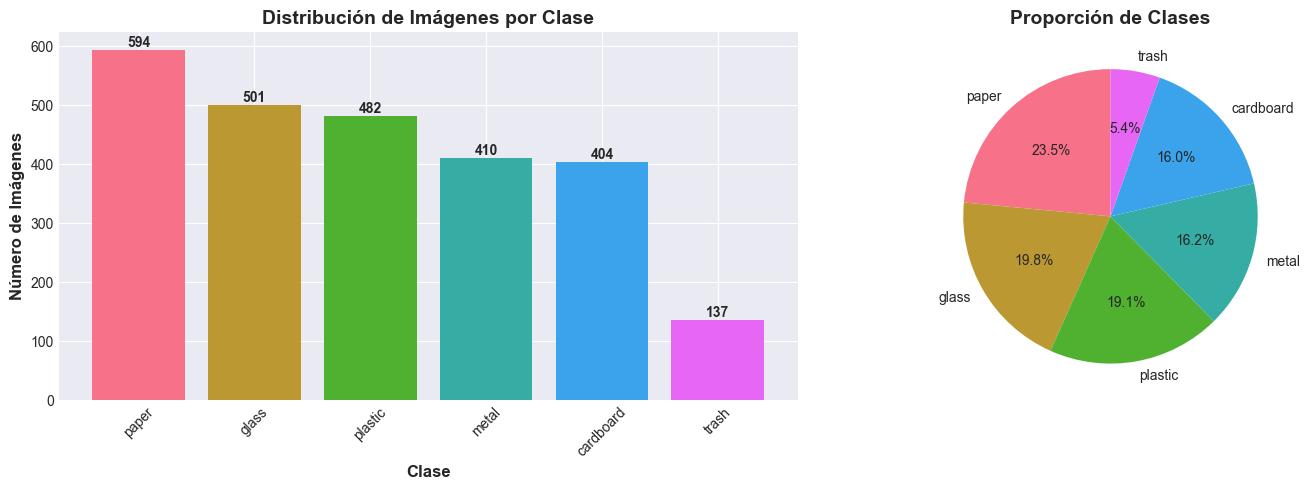


Análisis de Desbalanceo:
   Clase más numerosa: paper (594 imágenes)
   Clase menos numerosa: trash (137 imágenes)
   Ratio max/min: 4.34x
   ADVERTENCIA: El dataset está desbalanceado. Considera usar técnicas de balanceo.


In [ ]:
# Visualizar distribución
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de barras
colors = sns.color_palette('husl', len(df_counts))
bars = ax1.bar(df_counts['Clase'], df_counts['Cantidad'], color=colors)
ax1.set_xlabel('Clase', fontsize=12, fontweight='bold')
ax1.set_ylabel('Número de Imágenes', fontsize=12, fontweight='bold')
ax1.set_title('Distribución de Imágenes por Clase', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# Añadir etiquetas con valores
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold')

# Gráfico circular
ax2.pie(df_counts['Cantidad'], labels=df_counts['Clase'], autopct='%1.1f%%',
        startangle=90, colors=colors)
ax2.set_title('Proporción de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_distribucion_clases.png', dpi=300, bbox_inches='tight')
print(f'✅ Figura guardada: 01_distribucion_clases.png')
plt.show()

# Análisis de desbalanceo
max_count = df_counts['Cantidad'].max()
min_count = df_counts['Cantidad'].min()
ratio = max_count / min_count

print(f'\nAnálisis de Desbalanceo:')
print(f'   Clase más numerosa: {df_counts.iloc[0]["Clase"]} ({max_count} imágenes)')
print(f'   Clase menos numerosa: {df_counts.iloc[-1]["Clase"]} ({min_count} imágenes)')
print(f'   Ratio max/min: {ratio:.2f}x')

if ratio > 3:
    print('   ADVERTENCIA: El dataset está desbalanceado. Considera usar técnicas de balanceo.')
else:
    print('   El dataset está relativamente balanceado.')

## 4. Análisis de Características de las Imágenes

In [13]:
# Analizar una muestra de cada clase
print('Analizando características de las imágenes...\n')

SAMPLE_SIZE = 50
image_stats = []

for class_name in classes:
    class_path = DATA_DIR / class_name
    image_files = list(class_path.glob('*.jpg'))[:SAMPLE_SIZE]
    
    for img_path in image_files:
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                file_size = img_path.stat().st_size / 1024  # KB
                
                image_stats.append({
                    'clase': class_name,
                    'ancho': width,
                    'alto': height,
                    'aspecto': width / height,
                    'pixeles': width * height,
                    'tamaño_kb': file_size
                })
        except Exception as e:
            print(f'Error al procesar {img_path.name}: {e}')

df_stats = pd.DataFrame(image_stats)
print(f'Análisis completado: {len(df_stats)} imágenes analizadas\n')

Analizando características de las imágenes...

Análisis completado: 300 imágenes analizadas



In [14]:
# Estadísticas generales
print('Estadísticas Generales de las Imágenes:')
print('='*60)
print(f'Ancho medio: {df_stats["ancho"].mean():.1f} px (±{df_stats["ancho"].std():.1f})')
print(f'Alto medio: {df_stats["alto"].mean():.1f} px (±{df_stats["alto"].std():.1f})')
print(f'Ratio de aspecto medio: {df_stats["aspecto"].mean():.2f}')
print(f'Tamaño medio: {df_stats["tamaño_kb"].mean():.1f} KB')
print('='*60)

# Estadísticas por clase
print('\nEstadísticas por Clase:')
stats_by_class = df_stats.groupby('clase').agg({
    'ancho': 'mean',
    'alto': 'mean',
    'aspecto': 'mean',
    'tamaño_kb': 'mean'
}).round(1)

stats_by_class.columns = ['Ancho Medio', 'Alto Medio', 'Aspecto', 'Tamaño (KB)']
print(stats_by_class)

Estadísticas Generales de las Imágenes:
Ancho medio: 512.0 px (±0.0)
Alto medio: 384.0 px (±0.0)
Ratio de aspecto medio: 1.33
Tamaño medio: 16.3 KB

Estadísticas por Clase:
           Ancho Medio  Alto Medio  Aspecto  Tamaño (KB)
clase                                                   
cardboard        512.0       384.0      1.3         17.9
glass            512.0       384.0      1.3         13.2
metal            512.0       384.0      1.3         18.1
paper            512.0       384.0      1.3         22.2
plastic          512.0       384.0      1.3         13.4
trash            512.0       384.0      1.3         13.2


## 4.1. Visualización de Distribuciones por Clase

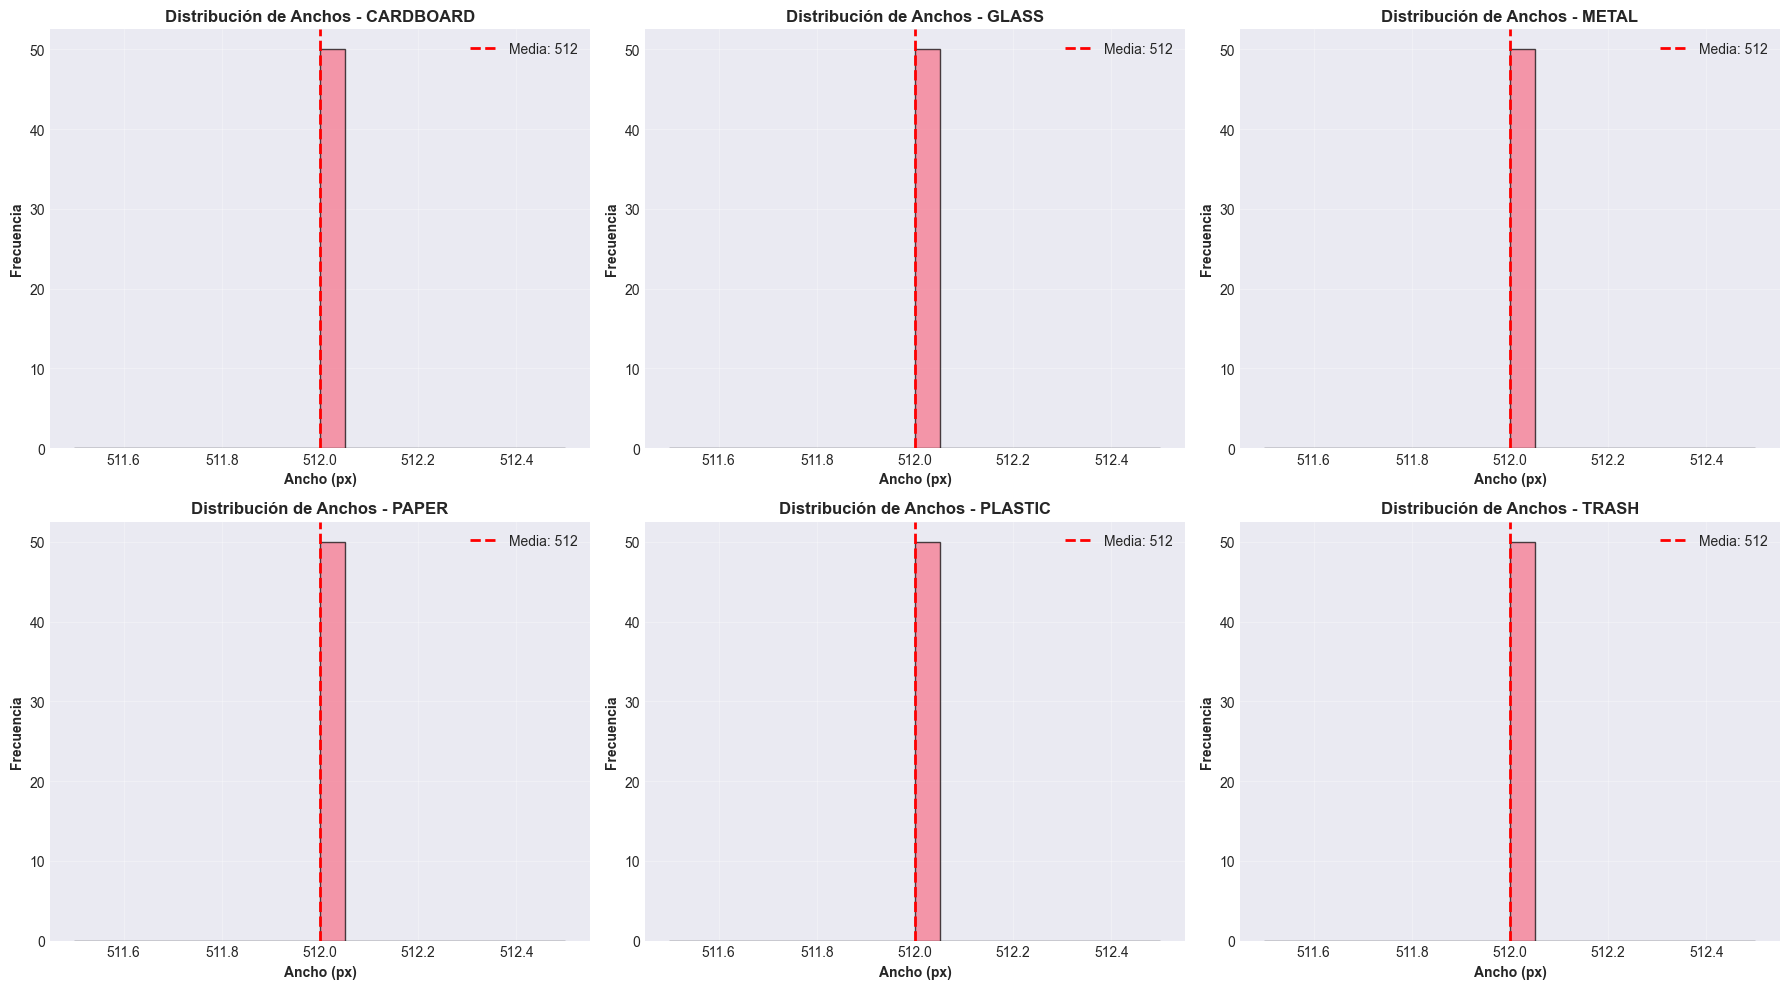

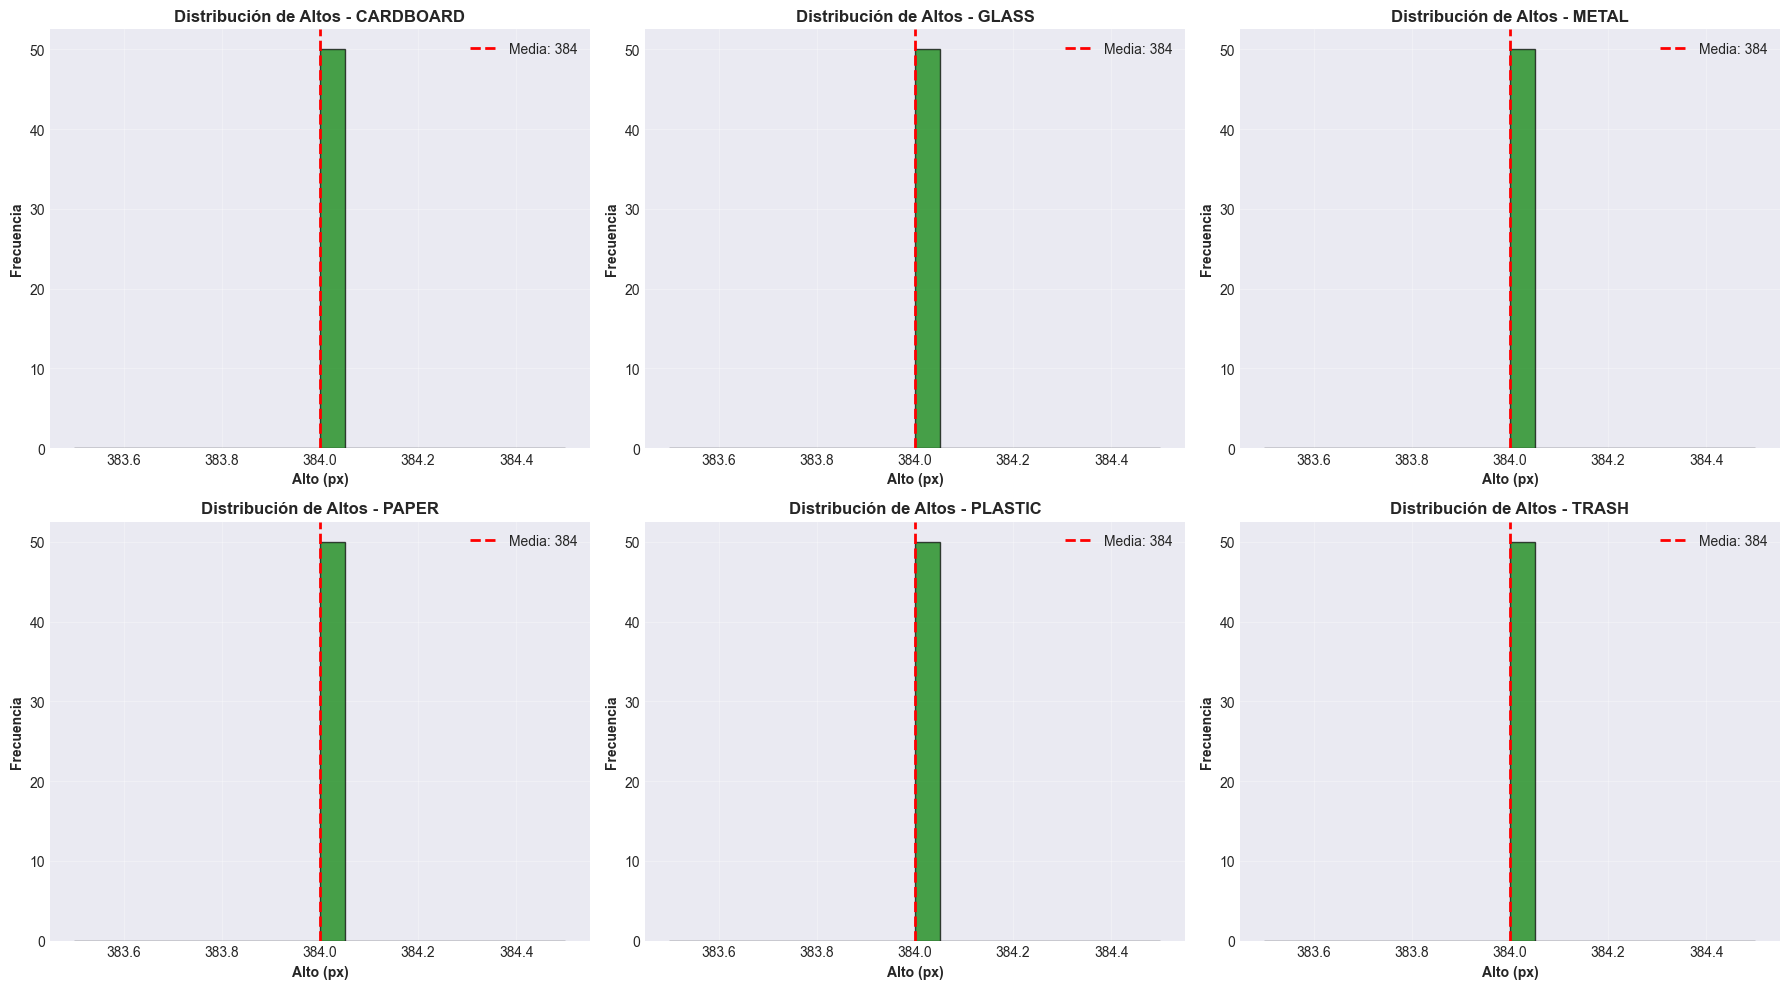

In [ ]:
# Histogramas de dimensiones por clase
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Histograma de anchos por clase
for i, class_name in enumerate(classes):
    class_data = df_stats[df_stats['clase'] == class_name]
    axes[i].hist(class_data['ancho'], bins=20, alpha=0.7, edgecolor='black')
    axes[i].set_xlabel('Ancho (px)', fontweight='bold')
    axes[i].set_ylabel('Frecuencia', fontweight='bold')
    axes[i].set_title(f'Distribución de Anchos - {class_name.upper()}', fontweight='bold')
    axes[i].axvline(class_data['ancho'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {class_data["ancho"].mean():.0f}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_histograma_anchos_por_clase.png', dpi=300, bbox_inches='tight')
print(f'✅ Figura guardada: 02_histograma_anchos_por_clase.png')
plt.show()

# Histograma de altos por clase
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, class_name in enumerate(classes):
    class_data = df_stats[df_stats['clase'] == class_name]
    axes[i].hist(class_data['alto'], bins=20, alpha=0.7, color='green', edgecolor='black')
    axes[i].set_xlabel('Alto (px)', fontweight='bold')
    axes[i].set_ylabel('Frecuencia', fontweight='bold')
    axes[i].set_title(f'Distribución de Altos - {class_name.upper()}', fontweight='bold')
    axes[i].axvline(class_data['alto'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {class_data["alto"].mean():.0f}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_histograma_altos_por_clase.png', dpi=300, bbox_inches='tight')
print(f'✅ Figura guardada: 03_histograma_altos_por_clase.png')
plt.show()

## 4.2. Boxplots Comparativos entre Clases

C:\Users\Andres\AppData\Local\Temp\ipykernel_30768\2239546016.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_stats, x='clase', y='ancho', ax=axes[0, 0], palette='husl')
C:\Users\Andres\AppData\Local\Temp\ipykernel_30768\2239546016.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_stats, x='clase', y='alto', ax=axes[0, 1], palette='husl')
C:\Users\Andres\AppData\Local\Temp\ipykernel_30768\2239546016.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_stats, x='clase', y='aspecto', ax=axes[1, 0], palette='husl'

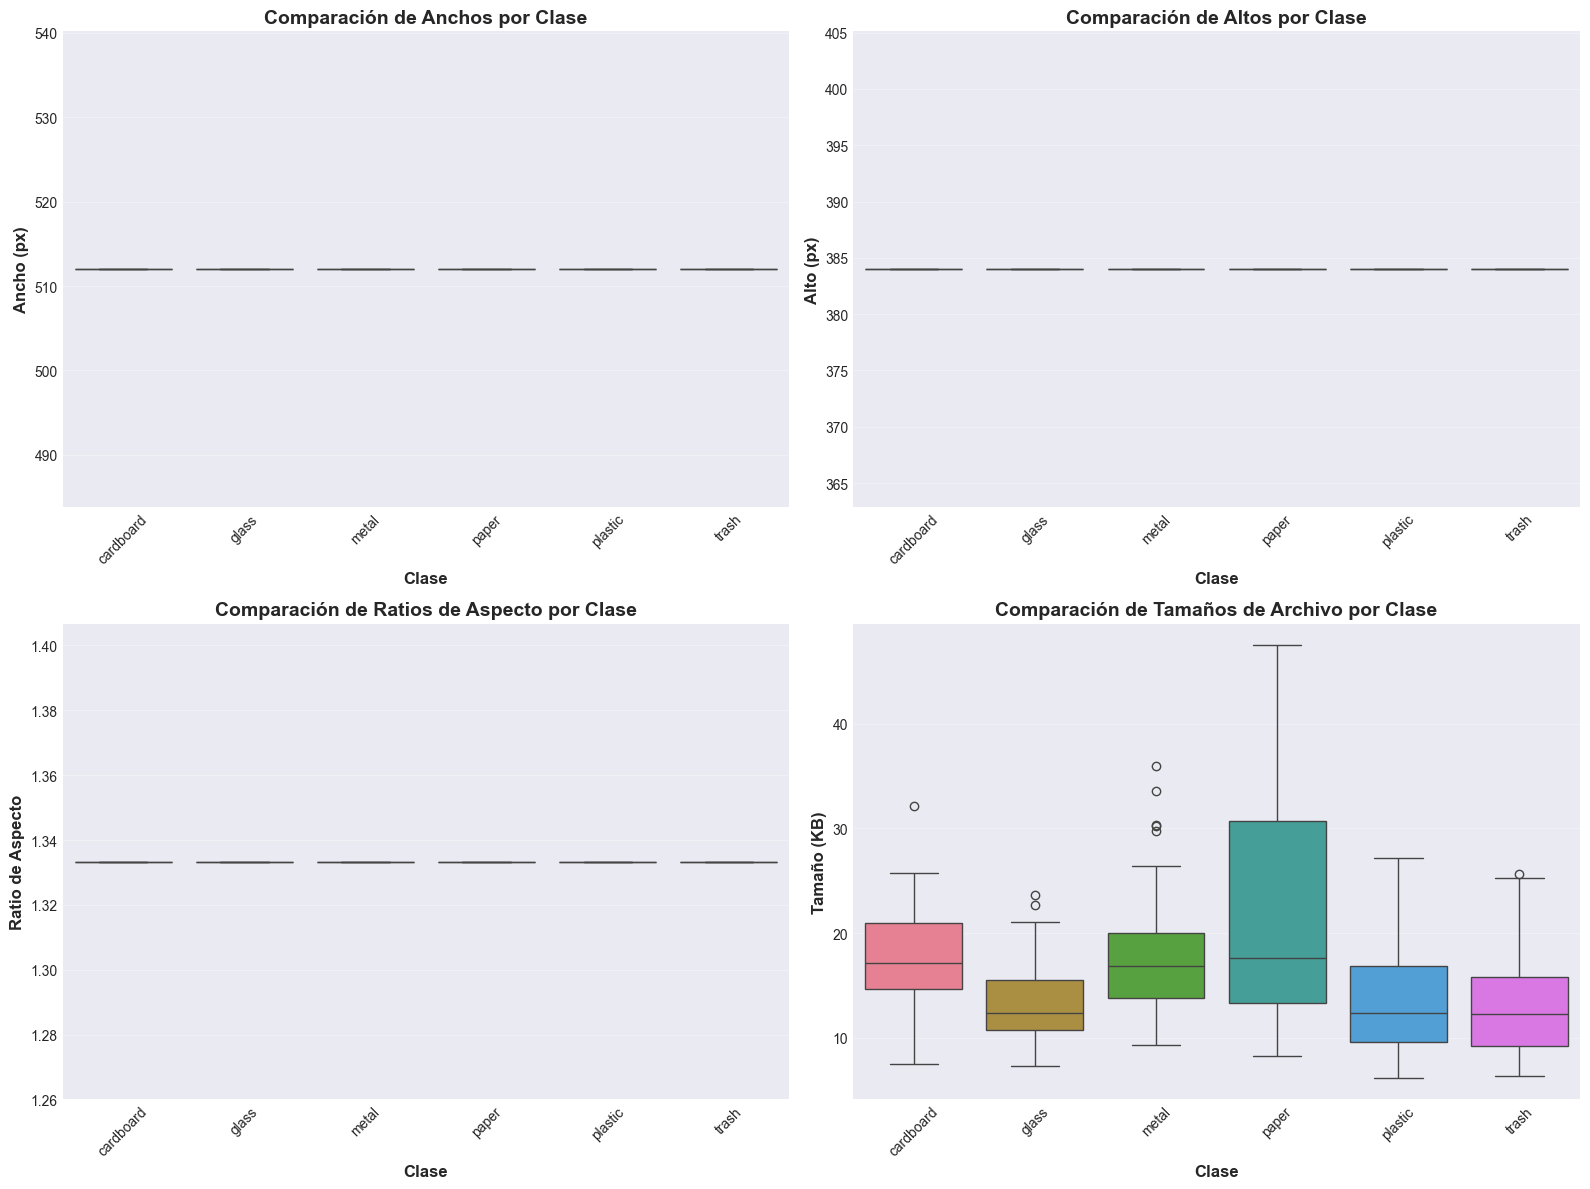


📊 Análisis de Variabilidad por Clase:
          ancho           alto           aspecto tamaño_kb
            std  min  max  std  min  max     std       std
clase                                                     
cardboard   0.0  512  512  0.0  384  384     0.0      5.28
glass       0.0  512  512  0.0  384  384     0.0      3.92
metal       0.0  512  512  0.0  384  384     0.0      6.11
paper       0.0  512  512  0.0  384  384     0.0     11.59
plastic     0.0  512  512  0.0  384  384     0.0      4.94
trash       0.0  512  512  0.0  384  384     0.0      5.09


In [ ]:
# Boxplots comparativos de todas las características
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Boxplot de anchos
sns.boxplot(data=df_stats, x='clase', y='ancho', ax=axes[0, 0], palette='husl')
axes[0, 0].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Ancho (px)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Comparación de Anchos por Clase', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Boxplot de altos
sns.boxplot(data=df_stats, x='clase', y='alto', ax=axes[0, 1], palette='husl')
axes[0, 1].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Alto (px)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Comparación de Altos por Clase', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Boxplot de ratio de aspecto
sns.boxplot(data=df_stats, x='clase', y='aspecto', ax=axes[1, 0], palette='husl')
axes[1, 0].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Ratio de Aspecto', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Comparación de Ratios de Aspecto por Clase', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Boxplot de tamaño de archivo
sns.boxplot(data=df_stats, x='clase', y='tamaño_kb', ax=axes[1, 1], palette='husl')
axes[1, 1].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Tamaño (KB)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Comparación de Tamaños de Archivo por Clase', fontsize=14, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_boxplots_comparativos.png', dpi=300, bbox_inches='tight')
print(f'✅ Figura guardada: 04_boxplots_comparativos.png')
plt.show()

# Mostrar estadísticas de variabilidad
print('\n📊 Análisis de Variabilidad por Clase:')
print('='*70)
variability = df_stats.groupby('clase').agg({
    'ancho': ['std', 'min', 'max'],
    'alto': ['std', 'min', 'max'],
    'aspecto': 'std',
    'tamaño_kb': 'std'
}).round(2)

print(variability)

## 4.3. Análisis de Características de Color

🎨 Analizando características de color...

✅ Análisis de color completado: 120 imágenes analizadas

✅ Análisis de color completado: 120 imágenes analizadas



C:\Users\Andres\AppData\Local\Temp\ipykernel_30768\1333624384.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_colors, x='clase', y='r_mean', ax=axes[0, 0], palette='Reds')
C:\Users\Andres\AppData\Local\Temp\ipykernel_30768\1333624384.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_colors, x='clase', y='g_mean', ax=axes[0, 1], palette='Greens')
C:\Users\Andres\AppData\Local\Temp\ipykernel_30768\1333624384.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_colors, x='clase', y='b_mean', ax=axes[1, 0], palett

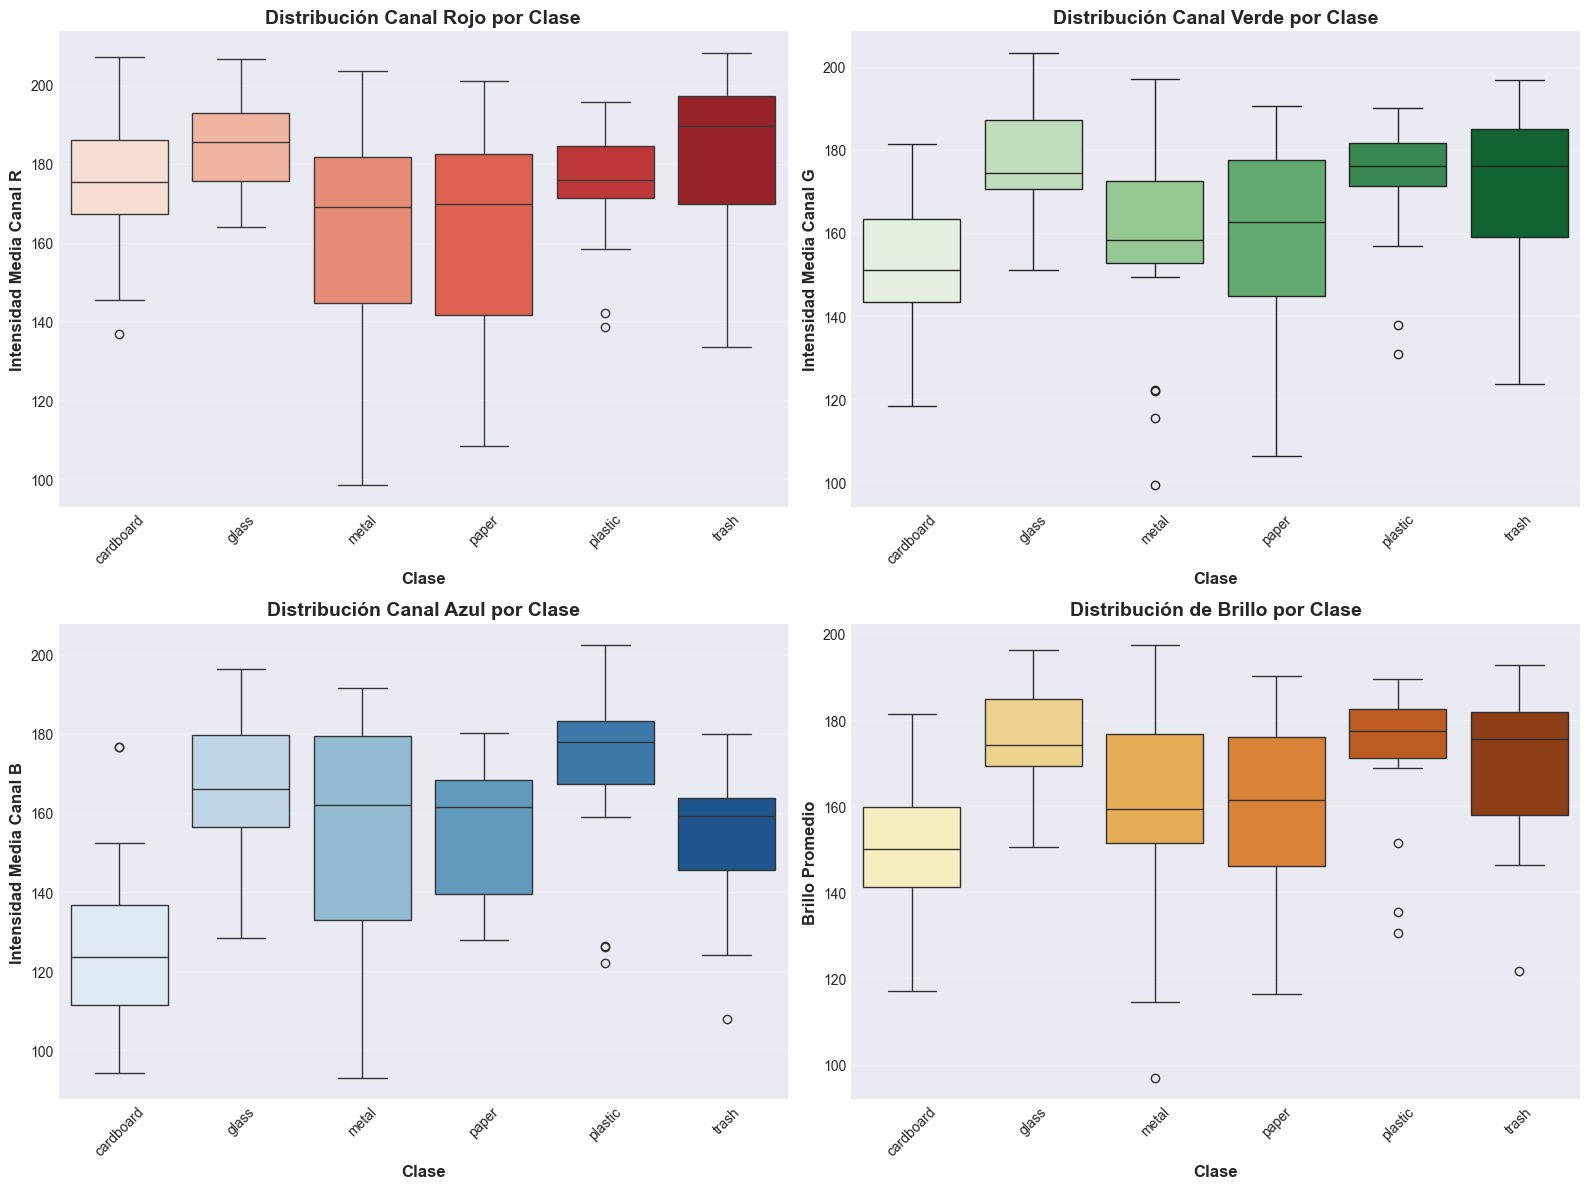

In [ ]:
# Analizar características de color de las imágenes
print('🎨 Analizando características de color...\n')

color_stats = []

for class_name in classes:
    class_path = DATA_DIR / class_name
    image_files = list(class_path.glob('*.jpg'))[:20]  # 20 imágenes por clase para análisis de color
    
    for img_path in image_files:
        try:
            with Image.open(img_path) as img:
                # Convertir a array numpy
                img_array = np.array(img)
                
                # Calcular estadísticas de cada canal RGB
                if len(img_array.shape) == 3:  # Imagen en color
                    r_mean = img_array[:,:,0].mean()
                    g_mean = img_array[:,:,1].mean()
                    b_mean = img_array[:,:,2].mean()
                    
                    r_std = img_array[:,:,0].std()
                    g_std = img_array[:,:,1].std()
                    b_std = img_array[:,:,2].std()
                    
                    # Brillo promedio
                    brightness = img_array.mean()
                    
                    # Contraste (desviación estándar)
                    contrast = img_array.std()
                    
                    color_stats.append({
                        'clase': class_name,
                        'r_mean': r_mean,
                        'g_mean': g_mean,
                        'b_mean': b_mean,
                        'r_std': r_std,
                        'g_std': g_std,
                        'b_std': b_std,
                        'brightness': brightness,
                        'contrast': contrast
                    })
        except Exception as e:
            continue

df_colors = pd.DataFrame(color_stats)
print(f'✅ Análisis de color completado: {len(df_colors)} imágenes analizadas\n')

# Visualizar distribuciones de color por clase
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribución de canal Rojo
sns.boxplot(data=df_colors, x='clase', y='r_mean', ax=axes[0, 0], palette='Reds')
axes[0, 0].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Intensidad Media Canal R', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Distribución Canal Rojo por Clase', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Distribución de canal Verde
sns.boxplot(data=df_colors, x='clase', y='g_mean', ax=axes[0, 1], palette='Greens')
axes[0, 1].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Intensidad Media Canal G', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Distribución Canal Verde por Clase', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Distribución de canal Azul
sns.boxplot(data=df_colors, x='clase', y='b_mean', ax=axes[1, 0], palette='Blues')
axes[1, 0].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Intensidad Media Canal B', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Distribución Canal Azul por Clase', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Distribución de Brillo
sns.boxplot(data=df_colors, x='clase', y='brightness', ax=axes[1, 1], palette='YlOrBr')
axes[1, 1].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Brillo Promedio', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Distribución de Brillo por Clase', fontsize=14, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_analisis_color_canales_rgb.png', dpi=300, bbox_inches='tight')
print(f'✅ Figura guardada: 05_analisis_color_canales_rgb.png')
plt.show()

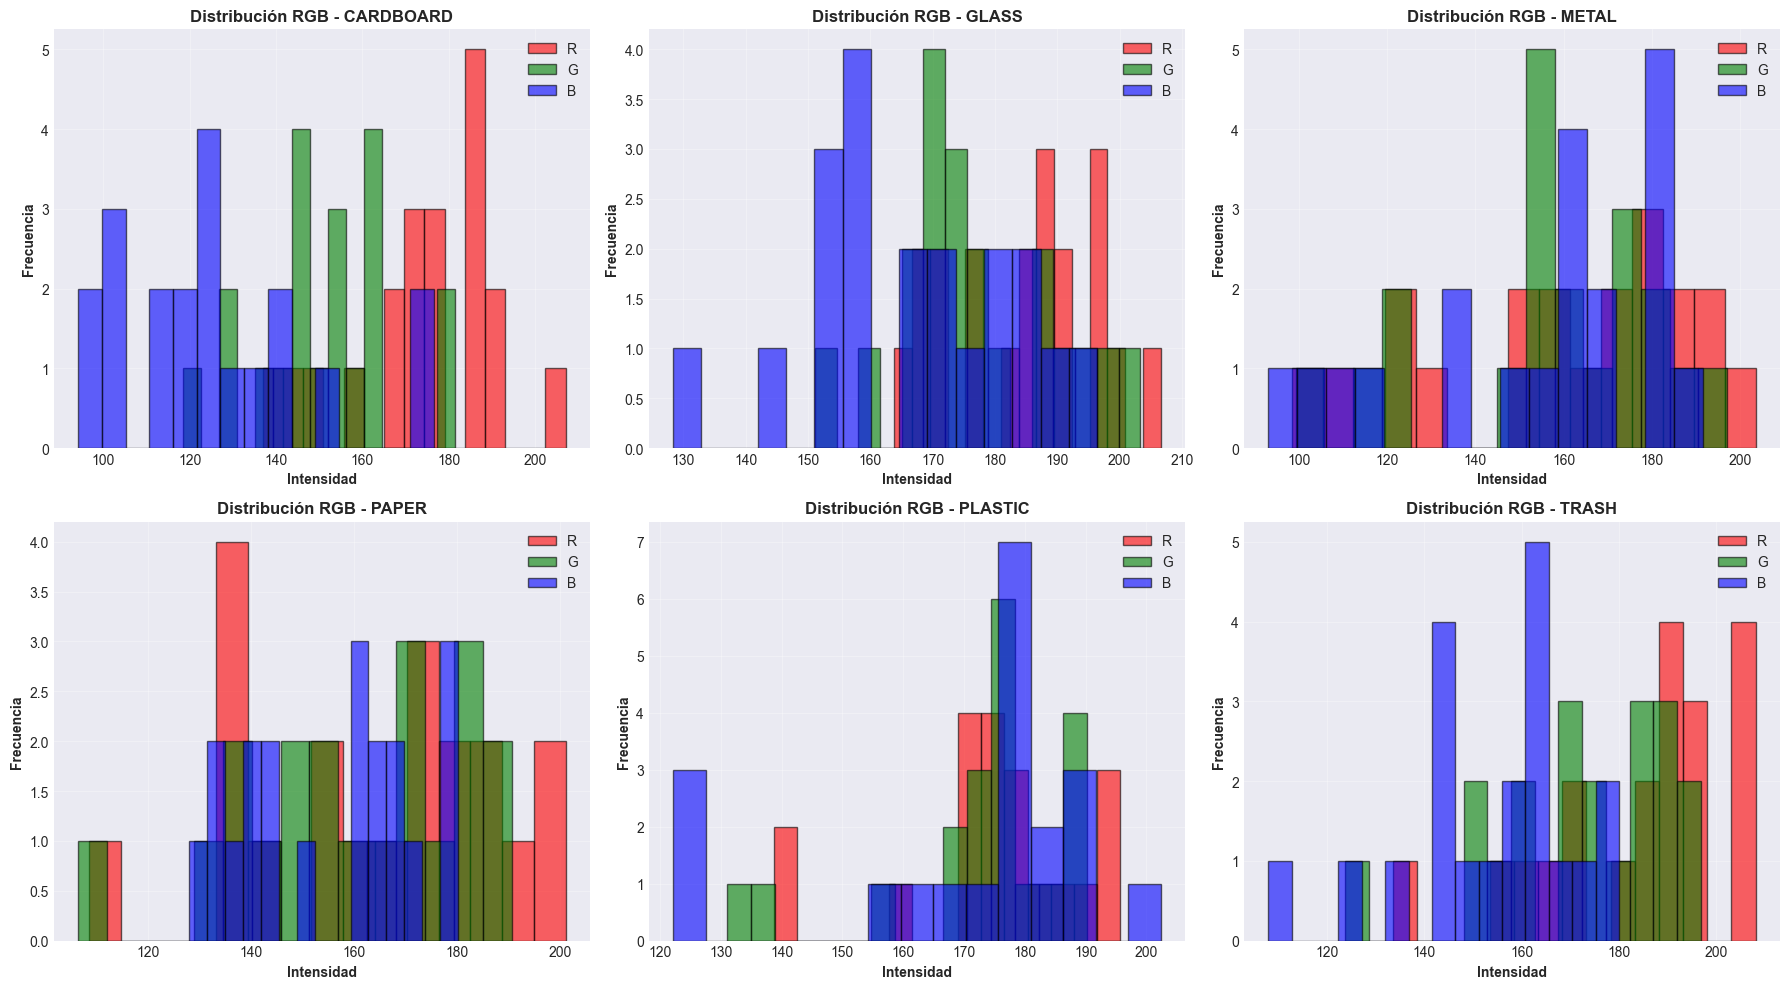


🎨 Perfil de Color Promedio por Clase:
             Rojo   Verde    Azul  Brillo  Contraste
clase                                               
cardboard  174.13  151.42  126.08  150.54      49.48
glass      184.61  177.16  166.94  176.24      49.80
metal      160.28  156.64  153.94  156.95      59.27
paper      164.17  159.66  155.42  159.75      55.64
plastic    175.18  173.03  171.48  173.23      43.10
trash      184.20  172.57  154.52  170.43      50.38


In [ ]:
# Histogramas de distribución RGB por clase
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, class_name in enumerate(classes):
    class_color_data = df_colors[df_colors['clase'] == class_name]
    
    # Histograma para cada canal RGB
    axes[i].hist(class_color_data['r_mean'], bins=15, alpha=0.6, color='red', label='R', edgecolor='black')
    axes[i].hist(class_color_data['g_mean'], bins=15, alpha=0.6, color='green', label='G', edgecolor='black')
    axes[i].hist(class_color_data['b_mean'], bins=15, alpha=0.6, color='blue', label='B', edgecolor='black')
    
    axes[i].set_xlabel('Intensidad', fontweight='bold')
    axes[i].set_ylabel('Frecuencia', fontweight='bold')
    axes[i].set_title(f'Distribución RGB - {class_name.upper()}', fontweight='bold')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_histogramas_rgb_por_clase.png', dpi=300, bbox_inches='tight')
print(f'✅ Figura guardada: 06_histogramas_rgb_por_clase.png')
plt.show()

# Perfil de color promedio por clase
print('\n🎨 Perfil de Color Promedio por Clase:')
print('='*70)
color_profile = df_colors.groupby('clase')[['r_mean', 'g_mean', 'b_mean', 'brightness', 'contrast']].mean().round(2)
color_profile.columns = ['Rojo', 'Verde', 'Azul', 'Brillo', 'Contraste']
print(color_profile)

## 4.4. Matriz de Correlación de Características

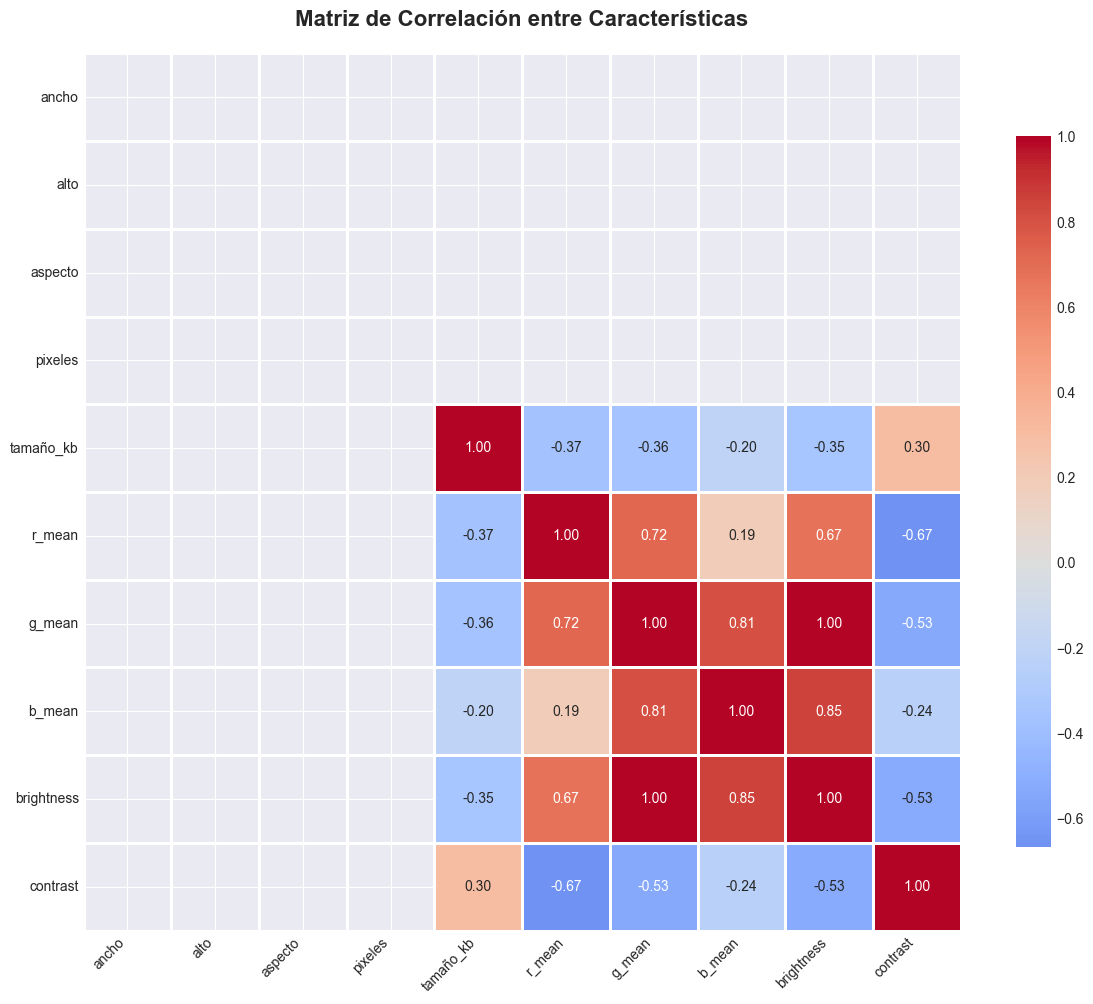


📊 Correlaciones Significativas (|r| > 0.7):
Variable 1 Variable 2  Correlación
    g_mean brightness     0.996182
    b_mean brightness     0.853558
    g_mean     b_mean     0.809804
    r_mean     g_mean     0.723771


In [ ]:
# Combinar características de dimensiones y color
df_combined = df_stats.merge(
    df_colors.groupby('clase').mean().reset_index(),
    on='clase',
    how='inner'
)

# Seleccionar características numéricas para correlación
feature_columns = ['ancho', 'alto', 'aspecto', 'pixeles', 'tamaño_kb', 
                   'r_mean', 'g_mean', 'b_mean', 'brightness', 'contrast']

# Calcular matriz de correlación
correlation_matrix = df_combined[feature_columns].corr()

# Visualizar matriz de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación entre Características', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_matriz_correlacion.png', dpi=300, bbox_inches='tight')
print(f'✅ Figura guardada: 07_matriz_correlacion.png')
plt.show()

# Identificar correlaciones fuertes
print('\n📊 Correlaciones Significativas (|r| > 0.7):')
print('='*70)

# Crear DataFrame de correlaciones
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            corr_pairs.append({
                'Variable 1': correlation_matrix.columns[i],
                'Variable 2': correlation_matrix.columns[j],
                'Correlación': corr_value
            })

if corr_pairs:
    df_corr = pd.DataFrame(corr_pairs).sort_values('Correlación', ascending=False, key=abs)
    print(df_corr.to_string(index=False))
else:
    print('No se encontraron correlaciones significativas (|r| > 0.7)')

## 4.5. Análisis de Variabilidad Intra-Clase

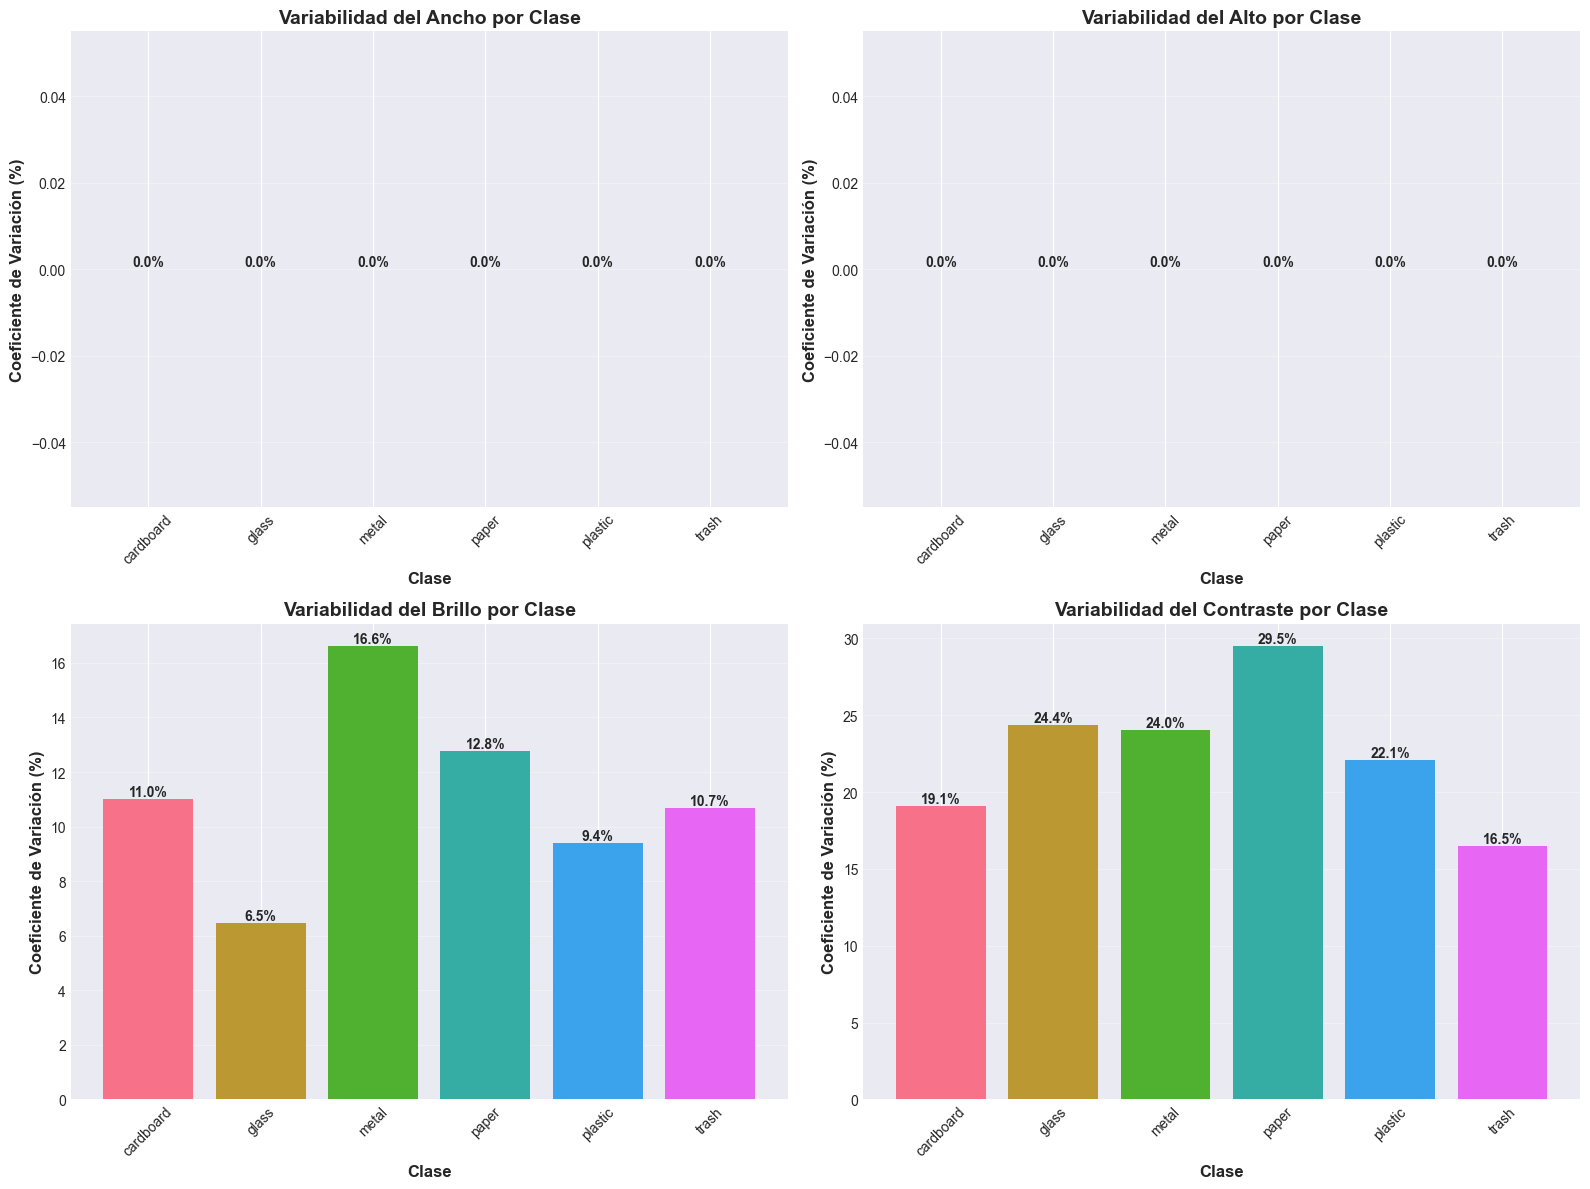


📊 Coeficientes de Variación por Clase:
(Valores más altos indican mayor variabilidad intra-clase)

    Clase  CV Ancho  CV Alto  CV Brillo  CV Contraste
cardboard       0.0      0.0      11.03         19.09
    glass       0.0      0.0       6.45         24.39
    metal       0.0      0.0      16.60         24.04
    paper       0.0      0.0      12.76         29.47
  plastic       0.0      0.0       9.39         22.11
    trash       0.0      0.0      10.69         16.48

💡 Interpretación:
   • CV < 15%: Baja variabilidad (imágenes muy homogéneas)
   • 15% ≤ CV < 30%: Variabilidad moderada
   • CV ≥ 30%: Alta variabilidad (imágenes muy diversas)


In [ ]:
# Calcular coeficiente de variación (CV) para cada clase
# CV = (desviación estándar / media) * 100

cv_stats = []

for class_name in classes:
    class_dim_data = df_stats[df_stats['clase'] == class_name]
    class_color_data = df_colors[df_colors['clase'] == class_name]
    
    cv_stats.append({
        'Clase': class_name,
        'CV Ancho': (class_dim_data['ancho'].std() / class_dim_data['ancho'].mean()) * 100,
        'CV Alto': (class_dim_data['alto'].std() / class_dim_data['alto'].mean()) * 100,
        'CV Brillo': (class_color_data['brightness'].std() / class_color_data['brightness'].mean()) * 100,
        'CV Contraste': (class_color_data['contrast'].std() / class_color_data['contrast'].mean()) * 100
    })

df_cv = pd.DataFrame(cv_stats)

# Visualizar coeficientes de variación
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# CV Ancho
axes[0, 0].bar(df_cv['Clase'], df_cv['CV Ancho'], color=sns.color_palette('husl', len(classes)))
axes[0, 0].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Coeficiente de Variación (%)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Variabilidad del Ancho por Clase', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(df_cv['CV Ancho']):
    axes[0, 0].text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

# CV Alto
axes[0, 1].bar(df_cv['Clase'], df_cv['CV Alto'], color=sns.color_palette('husl', len(classes)))
axes[0, 1].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Coeficiente de Variación (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Variabilidad del Alto por Clase', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(df_cv['CV Alto']):
    axes[0, 1].text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

# CV Brillo
axes[1, 0].bar(df_cv['Clase'], df_cv['CV Brillo'], color=sns.color_palette('husl', len(classes)))
axes[1, 0].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Coeficiente de Variación (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Variabilidad del Brillo por Clase', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(df_cv['CV Brillo']):
    axes[1, 0].text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

# CV Contraste
axes[1, 1].bar(df_cv['Clase'], df_cv['CV Contraste'], color=sns.color_palette('husl', len(classes)))
axes[1, 1].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Coeficiente de Variación (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Variabilidad del Contraste por Clase', fontsize=14, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(df_cv['CV Contraste']):
    axes[1, 1].text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_variabilidad_intraclase.png', dpi=300, bbox_inches='tight')
print(f'✅ Figura guardada: 08_variabilidad_intraclase.png')
plt.show()

# Mostrar tabla de coeficientes de variación
print('\n📊 Coeficientes de Variación por Clase:')
print('='*70)
print('(Valores más altos indican mayor variabilidad intra-clase)\n')
print(df_cv.round(2).to_string(index=False))

# Interpretar resultados
print('\n💡 Interpretación:')
print('   • CV < 15%: Baja variabilidad (imágenes muy homogéneas)')
print('   • 15% ≤ CV < 30%: Variabilidad moderada')
print('   • CV ≥ 30%: Alta variabilidad (imágenes muy diversas)')

## 5. Visualización de Muestras

Mostrando ejemplos de cada clase...



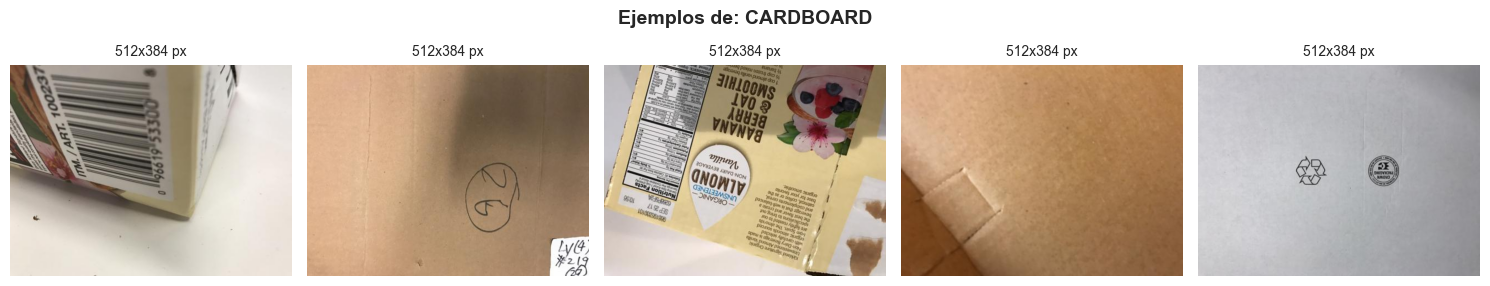

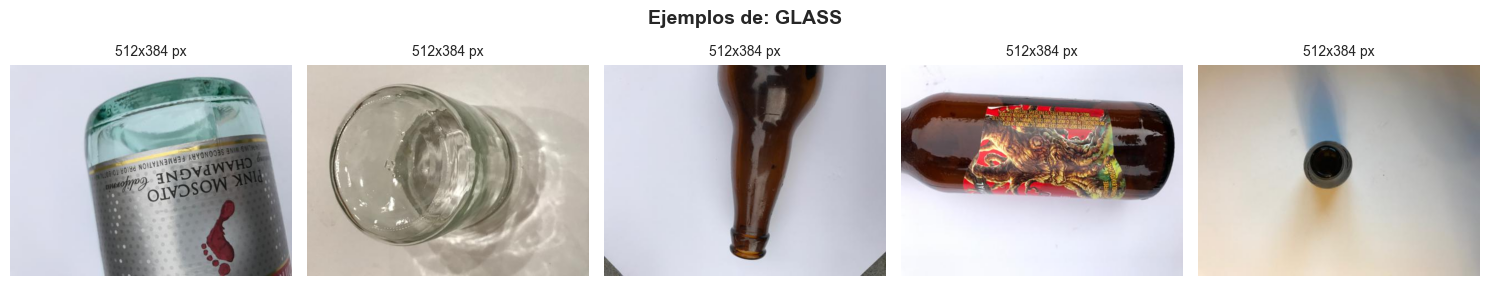

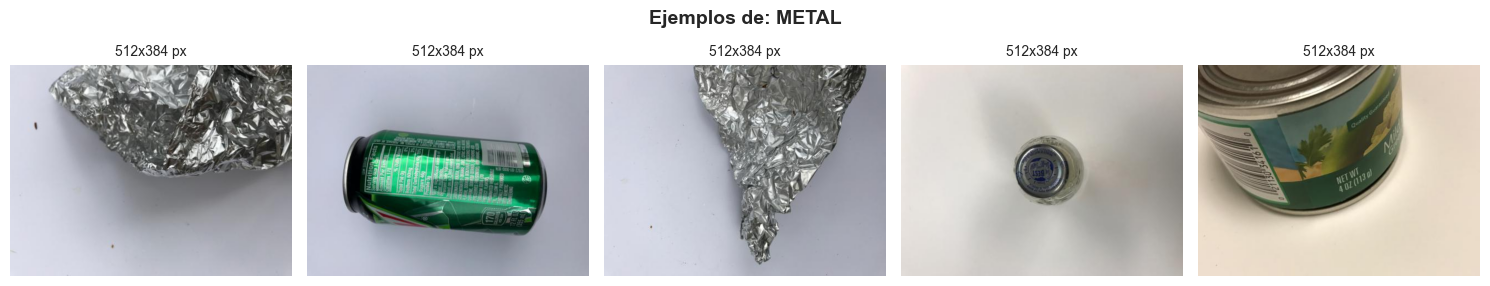

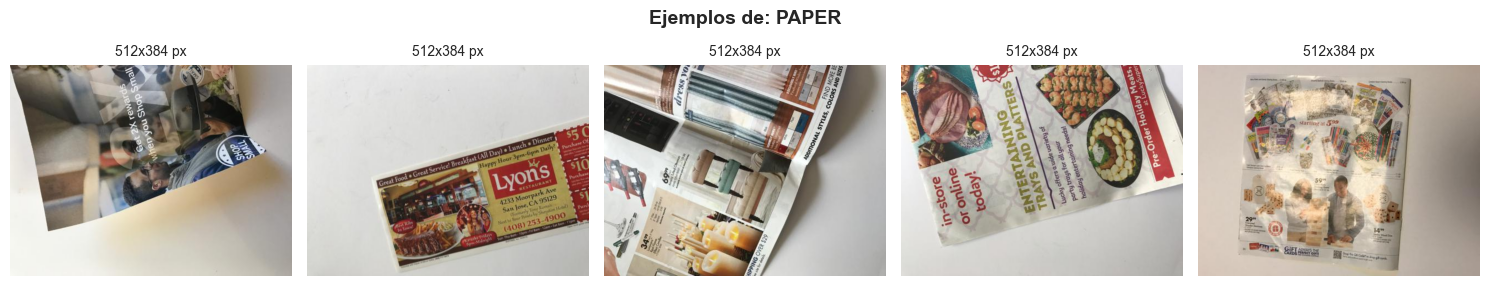

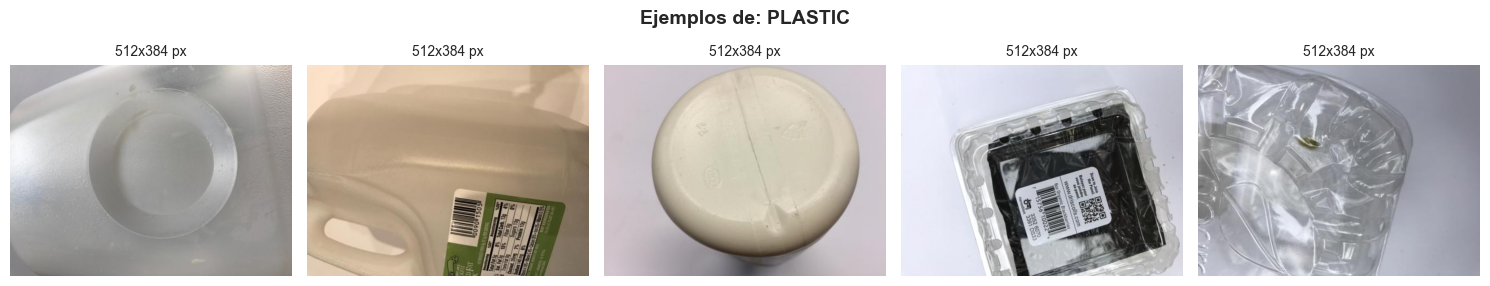

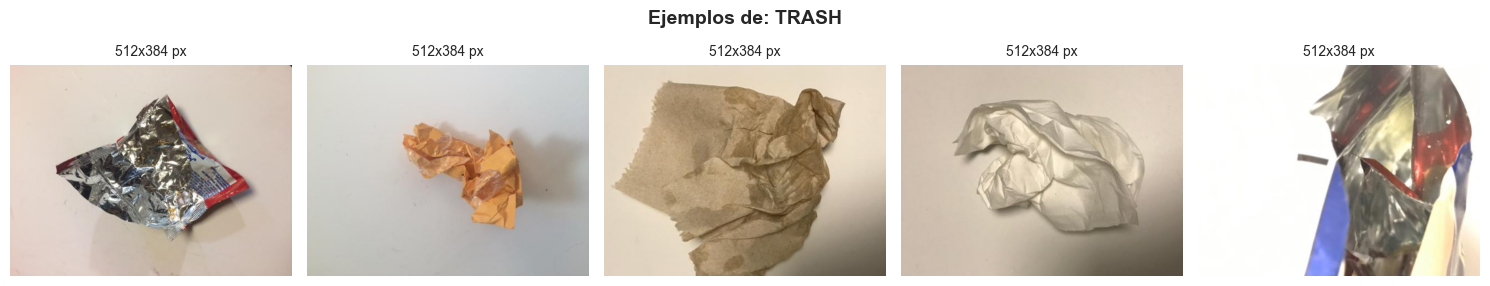

In [ ]:
# Función para mostrar imágenes de ejemplo
def show_samples(class_name, n_samples=5, save=False):
    class_path = DATA_DIR / class_name
    image_files = list(class_path.glob('*.jpg'))
    
    samples = np.random.choice(image_files, min(n_samples, len(image_files)), replace=False)
    
    fig, axes = plt.subplots(1, len(samples), figsize=(15, 3))
    if len(samples) == 1:
        axes = [axes]
    
    for ax, img_path in zip(axes, samples):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'{img.size[0]}x{img.size[1]} px', fontsize=10)
    
    fig.suptitle(f'Ejemplos de: {class_name.upper()}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save:
        plt.savefig(FIGURES_DIR / f'09_muestras_{class_name}.png', dpi=300, bbox_inches='tight')
        print(f'✅ Figura guardada: 09_muestras_{class_name}.png')
    
    plt.show()

# Mostrar ejemplos de cada clase
print('🖼️ Mostrando ejemplos de cada clase...\n')
for class_name in classes:
    show_samples(class_name, n_samples=5, save=True)

## 6. Resumen y Conclusiones

In [ ]:
print('='*70)
print('RESUMEN DEL ANÁLISIS EXPLORATORIO')
print('='*70)

print('\n📊 DATASET:')
print(f'   • Total de imágenes: {df_counts["Cantidad"].sum()}')
print(f'   • Número de clases: {len(classes)}')
print(f'   • Clases: {", ".join(classes)}')

print('\n⚖️ DISTRIBUCIÓN:')
print(f'   • Clase más numerosa: {df_counts.iloc[0]["Clase"]} ({df_counts.iloc[0]["Cantidad"]} imágenes)')
print(f'   • Clase menos numerosa: {df_counts.iloc[-1]["Clase"]} ({df_counts.iloc[-1]["Cantidad"]} imágenes)')
print(f'   • Ratio de desbalanceo: {(df_counts.iloc[0]["Cantidad"] / df_counts.iloc[-1]["Cantidad"]):.2f}x')

print('\n📐 CARACTERÍSTICAS DE IMÁGENES:')
print(f'   • Dimensión promedio: {df_stats["ancho"].mean():.0f}×{df_stats["alto"].mean():.0f} px')
print(f'   • Tamaño promedio: {df_stats["tamaño_kb"].mean():.1f} KB')
print(f'   • Ratio de aspecto promedio: {df_stats["aspecto"].mean():.2f}')

print('\n🎨 CARACTERÍSTICAS DE COLOR:')
print(f'   • Brillo promedio: {df_colors["brightness"].mean():.1f}')
print(f'   • Contraste promedio: {df_colors["contrast"].mean():.1f}')
print(f'   • Canal R promedio: {df_colors["r_mean"].mean():.1f}')
print(f'   • Canal G promedio: {df_colors["g_mean"].mean():.1f}')
print(f'   • Canal B promedio: {df_colors["b_mean"].mean():.1f}')

print('\n📈 VARIABILIDAD INTRA-CLASE:')
print(f'   • CV medio ancho: {df_cv["CV Ancho"].mean():.1f}%')
print(f'   • CV medio alto: {df_cv["CV Alto"].mean():.1f}%')
print(f'   • CV medio brillo: {df_cv["CV Brillo"].mean():.1f}%')

print('\n💡 RECOMENDACIONES:')
if (df_counts.iloc[0]['Cantidad'] / df_counts.iloc[-1]['Cantidad']) > 3:
    print('   ⚠️  Considerar técnicas de balanceo (augmentation, weighted loss)')
else:
    print('   ✅ El dataset está relativamente balanceado')

if df_stats['ancho'].std() > 100 or df_stats['alto'].std() > 100:
    print('   ⚠️  Normalizar dimensiones antes del entrenamiento')
else:
    print('   ✅ Dimensiones consistentes')

if df_cv['CV Ancho'].mean() > 30 or df_cv['CV Alto'].mean() > 30:
    print('   ⚠️  Alta variabilidad intra-clase: considerar data augmentation')
else:
    print('   ✅ Variabilidad intra-clase moderada')

print('\n📋 VISUALIZACIONES GENERADAS Y GUARDADAS:')
print(f'   ✓ 01_distribucion_clases.png')
print(f'   ✓ 02_histograma_anchos_por_clase.png')
print(f'   ✓ 03_histograma_altos_por_clase.png')
print(f'   ✓ 04_boxplots_comparativos.png')
print(f'   ✓ 05_analisis_color_canales_rgb.png')
print(f'   ✓ 06_histogramas_rgb_por_clase.png')
print(f'   ✓ 07_matriz_correlacion.png')
print(f'   ✓ 08_variabilidad_intraclase.png')
print(f'   ✓ 09_muestras_[clase].png (para cada clase)')

print(f'\n📁 Todas las figuras se han guardado en: {FIGURES_DIR}')

print('\n' + '='*70)
print('✅ Análisis completado exitosamente')
print('='*70)

RESUMEN DEL ANÁLISIS EXPLORATORIO

DATASET:
   Total de imágenes: 2528
   Número de clases: 6
   Clases: cardboard, glass, metal, paper, plastic, trash

DISTRIBUCIÓN:
   Clase más numerosa: paper (594 imágenes)
   Clase menos numerosa: trash (137 imágenes)
   Ratio de desbalanceo: 4.34x

CARACTERÍSTICAS DE IMÁGENES:
   Dimensión promedio: 512x384 px
   Tamaño promedio: 16.3 KB
   Ratio de aspecto promedio: 1.33

RECOMENDACIONES:
   Considerar técnicas de balanceo (augmentation, weighted loss)

Análisis completado exitosamente
